<a href="https://colab.research.google.com/github/rajshree23d/ecommerce-data-analysis/blob/main/Data_profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Olist E-Commerce Data Analysis

## Objective
Analyze e-commerce sales, customer behavior, product performance,
delivery performance, and customer satisfaction using Python.

## Tools
- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- Power BI

## Dataset
Brazilian E-Commerce Public Dataset by Olist

In [1]:
# ============================================
# OLIST E-COMMERCE ANALYTICS
# Advanced Data Analytics Portfolio Project
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries loaded successfully")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d')}")

data_path = "/content/drive/MyDrive/Colab Notebooks/Data_Analytics_portfolio/Olist_Ecommerce_Analytics"
os.listdir(data_path)
orders = pd.read_csv(
    f"{data_path}/olist_orders_dataset.csv"
)


# Load all CSVs
files = {
    'orders':        'olist_orders_dataset.csv',
    'order_items':   'olist_order_items_dataset.csv',
    'customers':     'olist_customers_dataset.csv',
    'products':      'olist_products_dataset.csv',
    'sellers':       'olist_sellers_dataset.csv',
    'payments':      'olist_order_payments_dataset.csv',
    'reviews':       'olist_order_reviews_dataset.csv',
    'category':      'product_category_name_translation.csv',
    'geolocation':   'olist_geolocation_dataset.csv'
}

dfs = {}
for name, file in files.items():
    path = os.path.join(data_path, file)
    dfs[name] = pd.read_csv(path)
    print(f"✅ {name:15} → {dfs[name].shape[0]:>7,} rows | {dfs[name].shape[1]:>2} cols")

# Unpack for easy access
orders       = dfs['orders']
order_items  = dfs['order_items']
customers    = dfs['customers']
products     = dfs['products']
sellers      = dfs['sellers']
payments     = dfs['payments']
reviews      = dfs['reviews']
category     = dfs['category']



✅ Libraries loaded successfully
📅 Analysis Date: 2026-09-15
✅ orders          →  99,441 rows |  8 cols
✅ order_items     → 112,650 rows |  7 cols
✅ customers       →  99,441 rows |  5 cols
✅ products        →  32,951 rows |  9 cols
✅ sellers         →   3,095 rows |  4 cols
✅ payments        → 103,886 rows |  5 cols
✅ reviews         →  99,224 rows |  7 cols
✅ category        →      71 rows |  2 cols
✅ geolocation     → 1,000,163 rows |  5 cols


In [2]:
# ============================================
# 2. DATA PROFILING — AUTOMATED REPORT
# ============================================

def profile_dataframe(df, name):
    """
    Generates a comprehensive data profile
    for any dataframe
    """
    print(f"\n{'='*60}")
    print(f" PROFILING: {name.upper()}")
    print(f"{'='*60}")
    print(f"  Shape:       {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Memory:      {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"  Duplicates:  {df.duplicated().sum():,}")

# Column-level profile
    profile = pd.DataFrame({
        'dtype':        df.dtypes,
        'null_count':   df.isnull().sum(),
        'null_pct':     (df.isnull().sum() / len(df) * 100).round(2),
        'unique_count': df.nunique(),
        'unique_pct':   (df.nunique() / len(df) * 100).round(2)
    })

# Add stats for numeric columns
    numeric_cols = df.select_dtypes(include=np.number).columns
    if len(numeric_cols) > 0:
        stats_df = df[numeric_cols].agg(['min','max','mean','median','std']).T
        profile = profile.join(stats_df, how='left')

    print(f"\n{profile.to_string()}")
    return profile

# Profile every dataset
profiles = {}
for name, df in dfs.items():
    if name != 'geolocation':  # skip large geo file
        profiles[name] = profile_dataframe(df, name)

print("\n✅ Data profiling complete")


 PROFILING: ORDERS
  Shape:       99,441 rows × 8 columns
  Memory:      52.94 MB
  Duplicates:  0

                                dtype  null_count  null_pct  unique_count  unique_pct
order_id                       object           0      0.00         99441      100.00
customer_id                    object           0      0.00         99441      100.00
order_status                   object           0      0.00             8        0.01
order_purchase_timestamp       object           0      0.00         98875       99.43
order_approved_at              object         160      0.16         90733       91.24
order_delivered_carrier_date   object        1783      1.79         81018       81.47
order_delivered_customer_date  object        2965      2.98         95664       96.20
order_estimated_delivery_date  object           0      0.00           459        0.46

 PROFILING: ORDER_ITEMS
  Shape:       112,650 rows × 7 columns
  Memory:      35.99 MB
  Duplicates:  0

                  

In [3]:
# ============================================
# 3. DATA CLEANING
# ============================================

print("🧹 Starting data cleaning...\n")

# ---- ORDERS ----
orders_clean = orders.copy()

# Convert all date columns
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    orders_clean[col] = pd.to_datetime(
        orders_clean[col], errors='coerce'
    )

    # Filter delivered orders only
orders_clean = orders_clean[
    orders_clean['order_status'] == 'delivered'
].copy()

# Remove nulls on critical delivery date
orders_clean = orders_clean.dropna(
    subset=['order_delivered_customer_date']
)

# Engineer date features
orders_clean['purchase_year']    = orders_clean['order_purchase_timestamp'].dt.year
orders_clean['purchase_month']   = orders_clean['order_purchase_timestamp'].dt.month
orders_clean['purchase_quarter'] = orders_clean['order_purchase_timestamp'].dt.quarter
orders_clean['purchase_dow']     = orders_clean['order_purchase_timestamp'].dt.dayofweek
orders_clean['purchase_hour']    = orders_clean['order_purchase_timestamp'].dt.hour

# Delivery metrics
orders_clean['delivery_days'] = (
    orders_clean['order_delivered_customer_date'] -
    orders_clean['order_purchase_timestamp']
).dt.days

orders_clean['approval_days'] = (
    orders_clean['order_approved_at'] -
    orders_clean['order_purchase_timestamp']
).dt.days

orders_clean['estimated_days'] = (
    orders_clean['order_estimated_delivery_date'] -
    orders_clean['order_purchase_timestamp']
).dt.days

orders_clean['on_time']         = (
    orders_clean['order_delivered_customer_date'] <=
    orders_clean['order_estimated_delivery_date']
)

orders_clean['early_late_days'] = (
    orders_clean['order_estimated_delivery_date'] -
    orders_clean['order_delivered_customer_date']
).dt.days  # positive = early, negative = late

# Remove delivery outliers
q_low  = orders_clean['delivery_days'].quantile(0.01)
q_high = orders_clean['delivery_days'].quantile(0.99)
orders_clean = orders_clean[
    orders_clean['delivery_days'].between(q_low, q_high)
]

print(f"✅ Orders cleaned: {len(orders_clean):,} delivered orders")

# ---- PRODUCTS ----
products_clean = products.copy()
products_clean['product_category_name'] = (
    products_clean['product_category_name'].fillna('unknown')
)
# Fill missing dimensions with median
dim_cols = [
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]
for col in dim_cols:
    products_clean[col] = products_clean[col].fillna(
        products_clean[col].median()
    )

    # Merge English category names
products_clean = products_clean.merge(
    category,
    on='product_category_name',
    how='left'
)
products_clean['category_en'] = (
    products_clean['product_category_name_english']
    .fillna(products_clean['product_category_name'])
)

print(f"✅ Products cleaned: {len(products_clean):,} products")

# ---- REVIEWS ----
reviews_clean = reviews.copy()
reviews_clean['review_creation_date'] = pd.to_datetime(
    reviews_clean['review_creation_date'], errors='coerce'
)
reviews_clean['review_comment_length'] = (
    reviews_clean['review_comment_message']
    .fillna('')
    .apply(len)
)
reviews_clean['has_comment'] = (
    reviews_clean['review_comment_message'].notna()
)

print(f"✅ Reviews cleaned: {len(reviews_clean):,} reviews")

# ---- PAYMENTS ----
payments_clean = payments.copy()
# Remove zero value payments
payments_clean = payments_clean[
    payments_clean['payment_value'] > 0
]

# Aggregate by order
payments_agg = payments_clean.groupby('order_id').agg(
    total_payment    = ('payment_value', 'sum'),
    payment_type     = ('payment_type', 'first'),
    installments     = ('payment_installments', 'max'),
    payment_count    = ('payment_sequential', 'count')
).reset_index()

print(f"✅ Payments aggregated: {len(payments_agg):,} orders")


🧹 Starting data cleaning...

✅ Orders cleaned: 95,577 delivered orders
✅ Products cleaned: 32,951 products
✅ Reviews cleaned: 99,224 reviews
✅ Payments aggregated: 99,437 orders


In [4]:
# ============================================
# 4. BUILD MASTER ANALYTICS TABLE
# ============================================

print("🔗 Building master analytics table...")

master = (
    order_items
    .merge(orders_clean,    on='order_id',    how='inner')
    .merge(customers,       on='customer_id', how='left')
    .merge(products_clean,  on='product_id',  how='left')
    .merge(payments_agg,    on='order_id',    how='left')
    .merge(
        reviews_clean[['order_id','review_score',
                        'has_comment','review_comment_length']],
        on='order_id', how='left'
    )
    .merge(
        sellers[['seller_id','seller_state','seller_city']],
        on='seller_id', how='left'
    )
)

# Revenue calculation
master['item_revenue']   = master['price'] + master['freight_value']
master['freight_ratio']  = (
    master['freight_value'] /
    master['price'].replace(0, np.nan)
).round(4)

# Price segments
master['price_segment'] = pd.cut(
    master['price'],
    bins=[0, 50, 100, 250, 500, float('inf')],
    labels=['Budget','Economy','Mid-Range','Premium','Luxury']
)

print(f"✅ Master table: {master.shape[0]:,} rows × {master.shape[1]} columns")

# Save master
master.to_csv(
    os.path.join(data_path, 'master_analytics.csv'),
    index=False
)
print("✅ Master table saved")

🔗 Building master analytics table...
✅ Master table: 109,845 rows × 50 columns
✅ Master table saved



 KEY BUSINESS METRICS SUMMARY
  Total Revenue             $15,299,513.59
  Total Orders              95,577
  Total Customers           95,577
  Total Products            32,042
  Avg Order Value           $160.08
  Avg Delivery Days         11.6
  On-Time Rate              92.9%
  Avg Review Score          4.10/5.0
  Avg Freight Ratio         32.1%


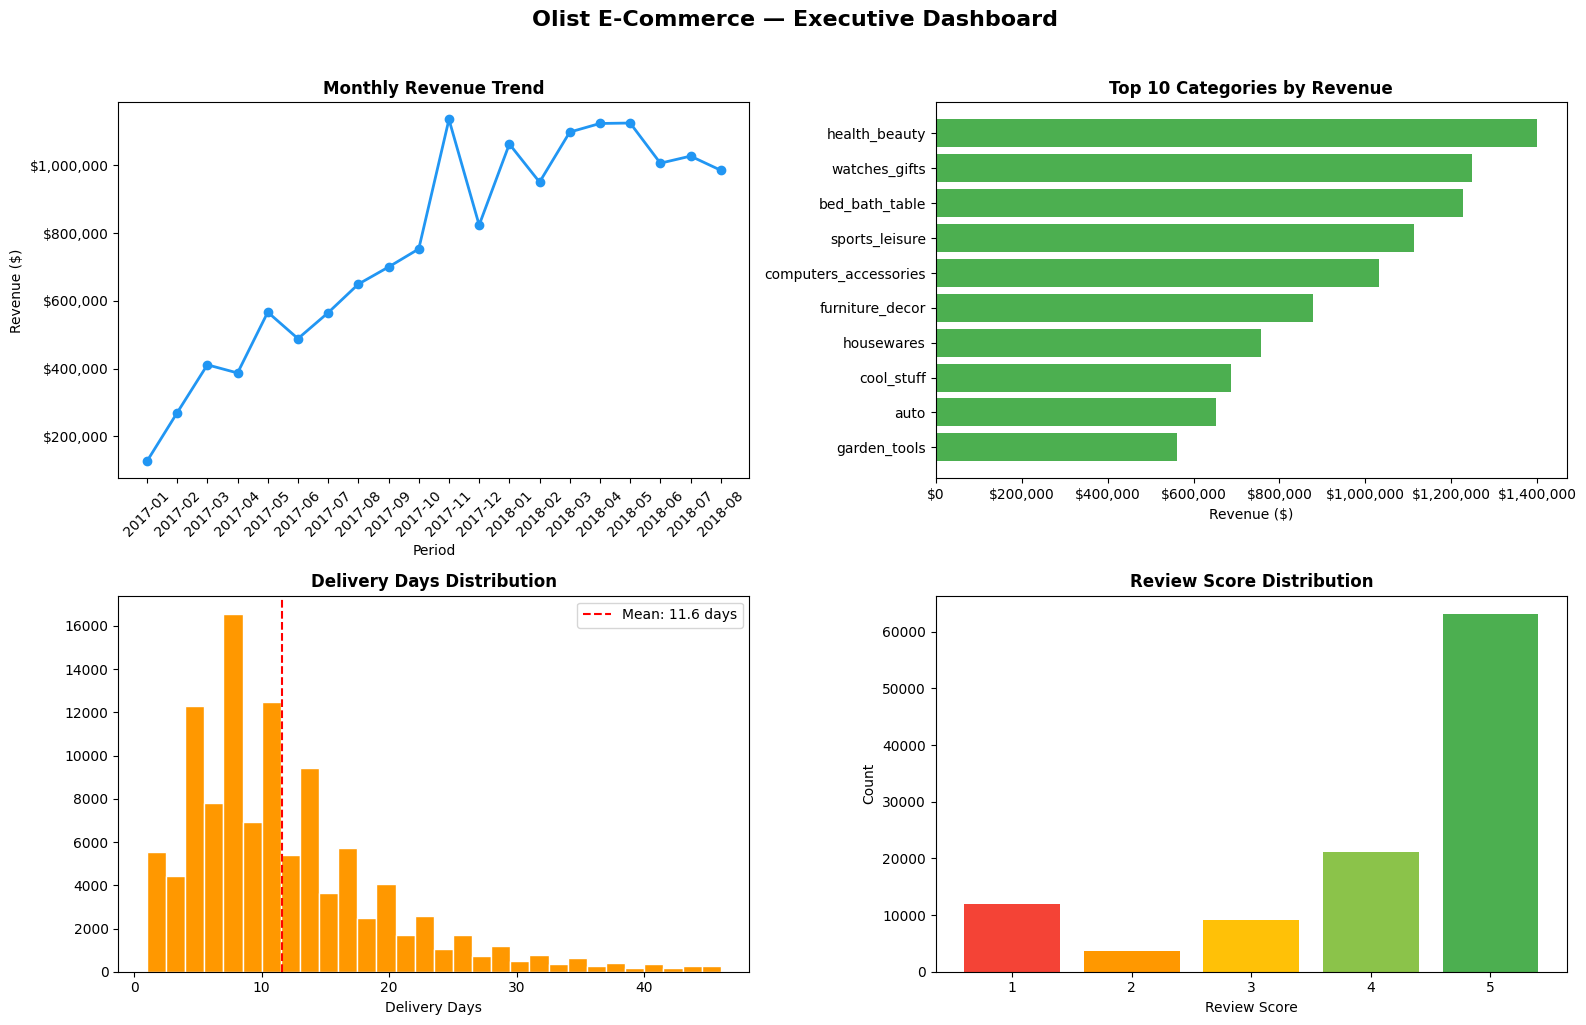

✅ Executive dashboard saved


In [5]:
# ============================================
# 5. EXPLORATORY DATA ANALYSIS
# ============================================

print("\n" + "="*60)
print(" KEY BUSINESS METRICS SUMMARY")
print("="*60)

metrics = {
    'Total Revenue':        f"${master['item_revenue'].sum():,.2f}",
    'Total Orders':         f"{master['order_id'].nunique():,}",
    'Total Customers':      f"{master['customer_id'].nunique():,}",
    'Total Products':       f"{master['product_id'].nunique():,}",
    'Avg Order Value':      f"${master.groupby('order_id')['item_revenue'].sum().mean():,.2f}",
    'Avg Delivery Days':    f"{master['delivery_days'].mean():.1f}",
    'On-Time Rate':         f"{master['on_time'].mean()*100:.1f}%",
    'Avg Review Score':     f"{master['review_score'].mean():.2f}/5.0",
    'Avg Freight Ratio':    f"{master['freight_ratio'].mean()*100:.1f}%"
}

for metric, value in metrics.items():
    print(f"  {metric:<25} {value}")

# ---- REVENUE TREND ----
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Olist E-Commerce — Executive Dashboard',
    fontsize=16, fontweight='bold', y=1.02
)

# Monthly revenue
monthly = (
    master.groupby(['purchase_year','purchase_month'])
    ['item_revenue'].sum()
    .reset_index()
)
monthly['period'] = (
    monthly['purchase_year'].astype(str) + '-' +
    monthly['purchase_month'].astype(str).str.zfill(2)
)
monthly = monthly[monthly['purchase_year'].isin([2017, 2018])]

axes[0,0].plot(
    monthly['period'], monthly['item_revenue'],
    marker='o', linewidth=2, color='#2196F3'
)
axes[0,0].set_title('Monthly Revenue Trend', fontweight='bold')
axes[0,0].set_xlabel('Period')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

# Top categories
top_cats = (
    master.groupby('category_en')['item_revenue']
    .sum()
    .sort_values(ascending=True)
    .tail(10)
)
axes[0,1].barh(
    top_cats.index, top_cats.values,
    color='#4CAF50'
)
axes[0,1].set_title('Top 10 Categories by Revenue', fontweight='bold')
axes[0,1].set_xlabel('Revenue ($)')
axes[0,1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x:,.0f}')
)

# Delivery distribution
axes[1,0].hist(
    master['delivery_days'].dropna(),
    bins=30, color='#FF9800', edgecolor='white'
)
axes[1,0].axvline(
    master['delivery_days'].mean(),
    color='red', linestyle='--',
    label=f"Mean: {master['delivery_days'].mean():.1f} days"
)
axes[1,0].set_title('Delivery Days Distribution', fontweight='bold')
axes[1,0].set_xlabel('Delivery Days')
axes[1,0].legend()

# Review score distribution
review_dist = master['review_score'].value_counts().sort_index()
colors = ['#f44336','#FF9800','#FFC107','#8BC34A','#4CAF50']
axes[1,1].bar(
    review_dist.index, review_dist.values,
    color=colors
)
axes[1,1].set_title('Review Score Distribution', fontweight='bold')
axes[1,1].set_xlabel('Review Score')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(
    os.path.join(data_path, 'executive_dashboard.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Executive dashboard saved")

👥 Running RFM Analysis...

RFM Segment Summary:
                     customers  avg_spend  avg_freq
segment                                            
At Risk                  22931     160.98      1.00
Loyal                    19214     158.63      1.00
New Customers            15432     161.84      1.00
Champions                15201     163.87      1.00
Lost                     15091     161.02      1.00
Potential Loyalists       7708     148.11      1.00


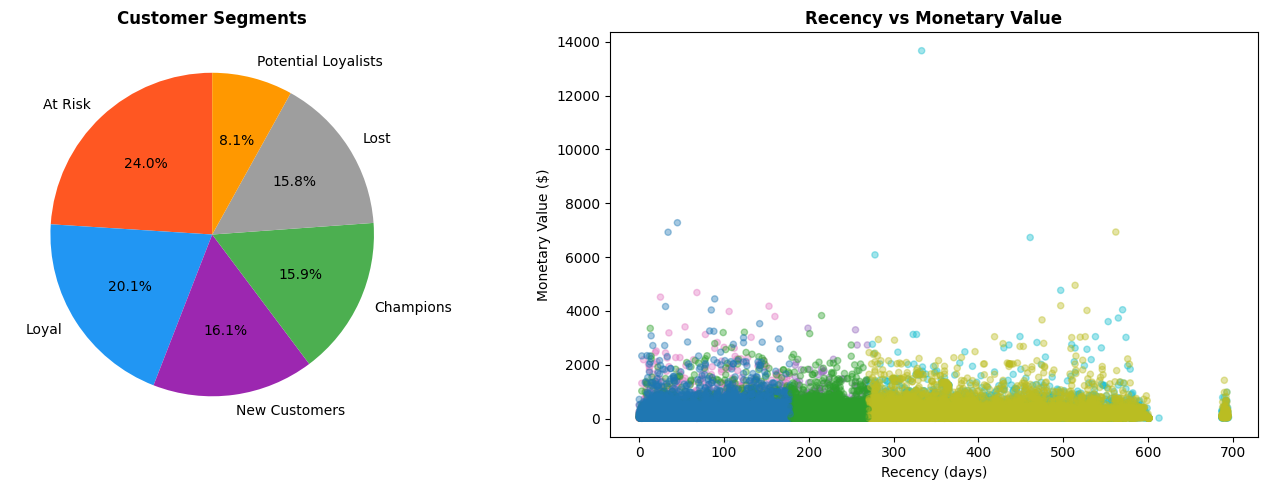

✅ RFM analysis complete and saved


In [6]:
# ============================================
# 6. RFM CUSTOMER SEGMENTATION
# ============================================

print("👥 Running RFM Analysis...")

snapshot = master['order_purchase_timestamp'].max()

rfm = (
    master.groupby('customer_id')
    .agg(
        recency   = ('order_purchase_timestamp',
                     lambda x: (snapshot - x.max()).days),
        frequency = ('order_id', 'nunique'),
        monetary  = ('item_revenue', 'sum')
    )
    .reset_index()
)

# Score 1-5
rfm['R'] = pd.qcut(rfm['recency'],   5, labels=[5,4,3,2,1])
rfm['F'] = pd.qcut(
    rfm['frequency'].rank(method='first'), 5,
    labels=[1,2,3,4,5]
)
rfm['M'] = pd.qcut(rfm['monetary'],  5, labels=[1,2,3,4,5])

rfm['RFM_score'] = (
    rfm['R'].astype(int) +
    rfm['F'].astype(int) +
    rfm['M'].astype(int)
)

# Segment
def segment(row):
    r, f = int(row['R']), int(row['F'])
    if r >= 4 and f >= 4:   return 'Champions'
    elif r >= 3 and f >= 3: return 'Loyal'
    elif r >= 4 and f <= 2: return 'New Customers'
    elif r <= 2 and f >= 3: return 'At Risk'
    elif r <= 2 and f <= 2: return 'Lost'
    else:                   return 'Potential Loyalists'

rfm['segment'] = rfm.apply(segment, axis=1)

# Summary
seg_summary = rfm.groupby('segment').agg(
    customers = ('customer_id', 'count'),
    avg_spend = ('monetary', 'mean'),
    avg_freq  = ('frequency', 'mean')
).round(2).sort_values('customers', ascending=False)

print("\nRFM Segment Summary:")
print(seg_summary)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_colors = {
    'Champions':          '#4CAF50',
    'Loyal':              '#2196F3',
    'Potential Loyalists':'#FF9800',
    'New Customers':      '#9C27B0',
    'At Risk':            '#FF5722',
    'Lost':               '#9E9E9E'
}

seg_counts = rfm['segment'].value_counts()
axes[0].pie(
    seg_counts.values,
    labels=seg_counts.index,
    colors=[seg_colors.get(s, '#9E9E9E')
            for s in seg_counts.index],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Customer Segments', fontweight='bold')

axes[1].scatter(
    rfm['recency'],
    rfm['monetary'],
    c=[list(seg_colors.keys()).index(s)
       if s in seg_colors else 0
       for s in rfm['segment']],
    alpha=0.4, cmap='tab10', s=20
)
axes[1].set_title('Recency vs Monetary Value', fontweight='bold')
axes[1].set_xlabel('Recency (days)')
axes[1].set_ylabel('Monetary Value ($)')

plt.tight_layout()
plt.savefig(
    os.path.join(data_path, 'rfm_analysis.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()

rfm.to_csv(os.path.join(data_path, 'rfm_segments.csv'), index=False)
print("✅ RFM analysis complete and saved")

📊 Running Cohort Analysis...


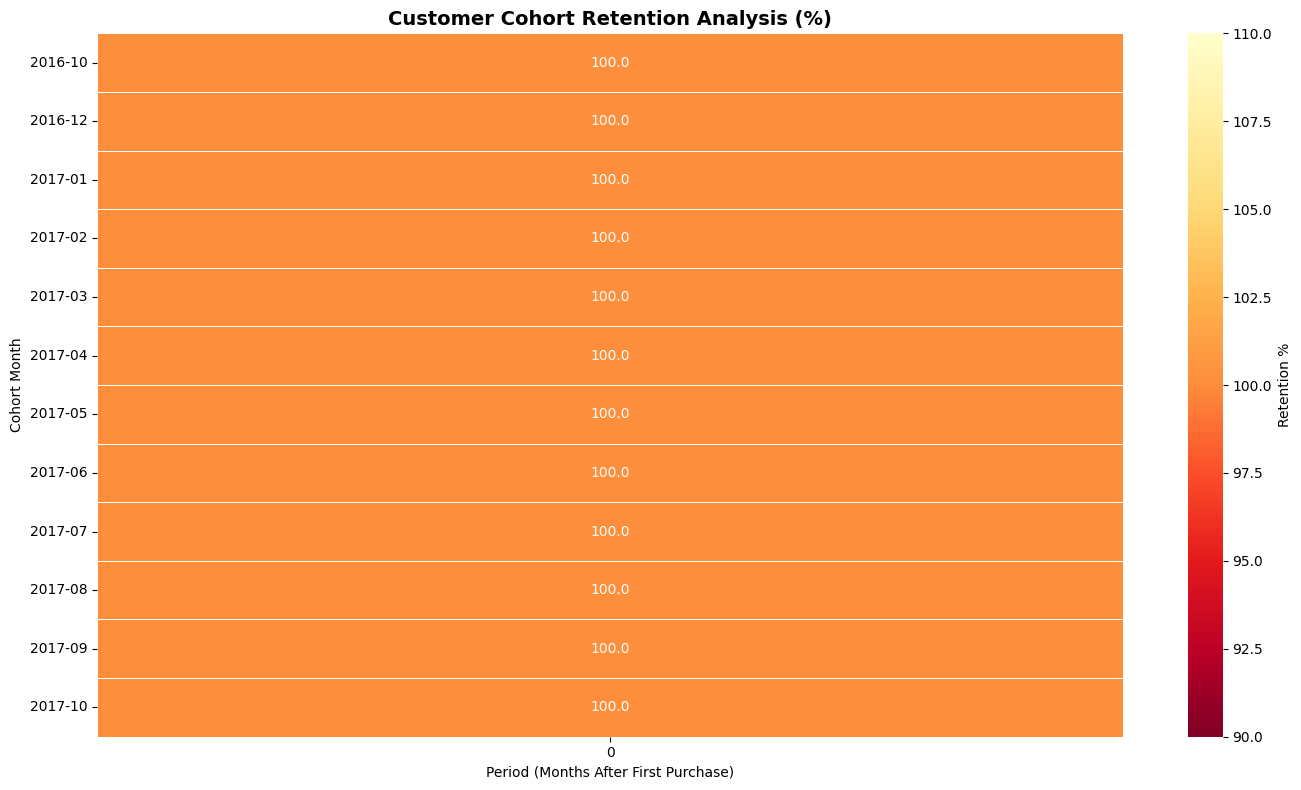

✅ Cohort analysis complete


In [7]:
# ============================================
# 7. COHORT RETENTION ANALYSIS
# ============================================

print("📊 Running Cohort Analysis...")

# First purchase month per customer
cohort_df = master[['customer_id','order_purchase_timestamp']].copy()
cohort_df['order_month'] = (
    cohort_df['order_purchase_timestamp']
    .dt.to_period('M')
)

first_purchase = (
    cohort_df.groupby('customer_id')['order_month']
    .min()
    .reset_index()
    .rename(columns={'order_month': 'cohort_month'})
)

cohort_df = cohort_df.merge(first_purchase, on='customer_id')
cohort_df['period_number'] = (
    cohort_df['order_month'] -
    cohort_df['cohort_month']
).apply(lambda x: x.n)

cohort_pivot = (
    cohort_df.groupby(['cohort_month','period_number'])
    ['customer_id'].nunique()
    .unstack()
)

cohort_size   = cohort_pivot.iloc[:, 0]
retention     = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

# Plot heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    retention.iloc[:12, :6],
    annot=True, fmt='.1f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    cbar_kws={'label': 'Retention %'}
)
plt.title(
    'Customer Cohort Retention Analysis (%)',
    fontsize=14, fontweight='bold'
)
plt.xlabel('Period (Months After First Purchase)')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig(
    os.path.join(data_path, 'cohort_retention.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Cohort analysis complete")

🔍 Running Outlier Detection...

price:
  Method:   IQR
  Outliers: 8,111 (7.38%)
  Range:    $-99.39 — $272.05

freight_value:
  Method:   IQR
  Outliers: 11,639 (10.60%)
  Range:    $0.95 — $33.19

item_revenue:
  Method:   IQR
  Outliers: 7,912 (7.20%)
  Range:    $-98.08 — $310.37

delivery_days:
  Method:   IQR
  Outliers: 4,614 (4.20%)
  Range:    $-7.50 — $28.50


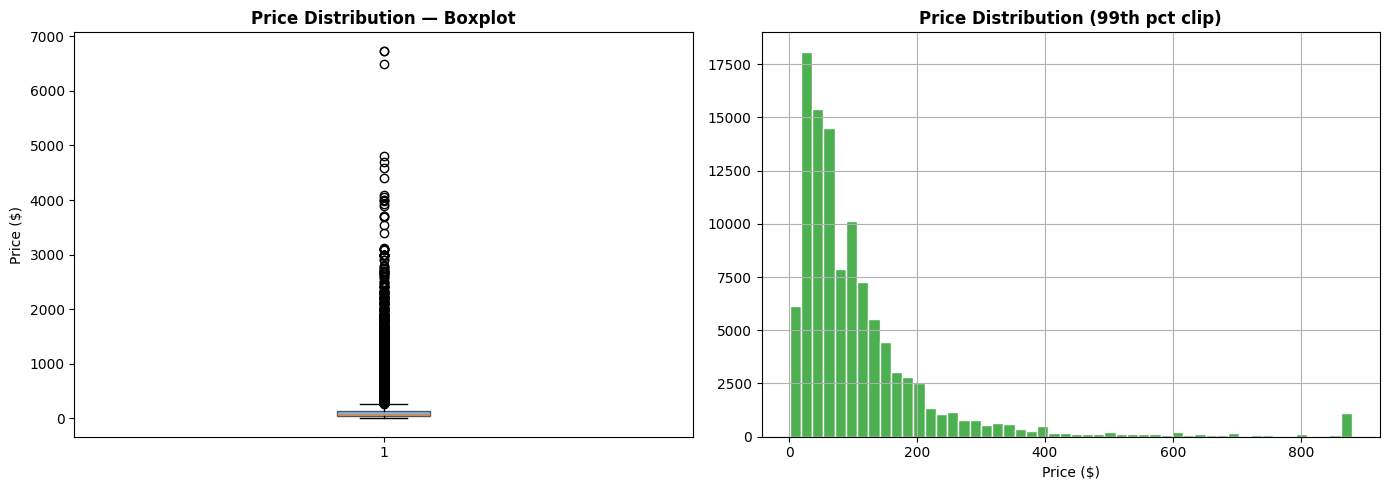

✅ Outlier detection complete


In [8]:
# ============================================
# 8. STATISTICAL OUTLIER DETECTION
# ============================================

print("🔍 Running Outlier Detection...")

def detect_outliers(df, col, method='iqr'):
    """Detect outliers using IQR or Z-score"""
    if method == 'iqr':
        Q1    = df[col].quantile(0.25)
        Q3    = df[col].quantile(0.75)
        IQR   = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        mask  = (df[col] < lower) | (df[col] > upper)
    else:
        z     = np.abs(stats.zscore(df[col].dropna()))
        mask  = z > 3

    outliers = df[mask]
    print(f"\n{col}:")
    print(f"  Method:   {method.upper()}")
    print(f"  Outliers: {mask.sum():,} ({mask.mean()*100:.2f}%)")
    if method == 'iqr':
        print(f"  Range:    ${lower:,.2f} — ${upper:,.2f}")
    return outliers

# Check key numeric columns
for col in ['price', 'freight_value', 'item_revenue', 'delivery_days']:
    detect_outliers(master, col, method='iqr')

# Price outlier visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    master['price'].dropna(),
    vert=True, patch_artist=True,
    boxprops=dict(facecolor='#2196F3', alpha=0.6)
)
axes[0].set_title('Price Distribution — Boxplot', fontweight='bold')
axes[0].set_ylabel('Price ($)')

master['price'].clip(
    upper=master['price'].quantile(0.99)
).hist(bins=50, ax=axes[1], color='#4CAF50', edgecolor='white')
axes[1].set_title('Price Distribution (99th pct clip)', fontweight='bold')
axes[1].set_xlabel('Price ($)')

plt.tight_layout()
plt.savefig(
    os.path.join(data_path, 'outlier_analysis.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Outlier detection complete")

📐 Running Statistical Analysis...


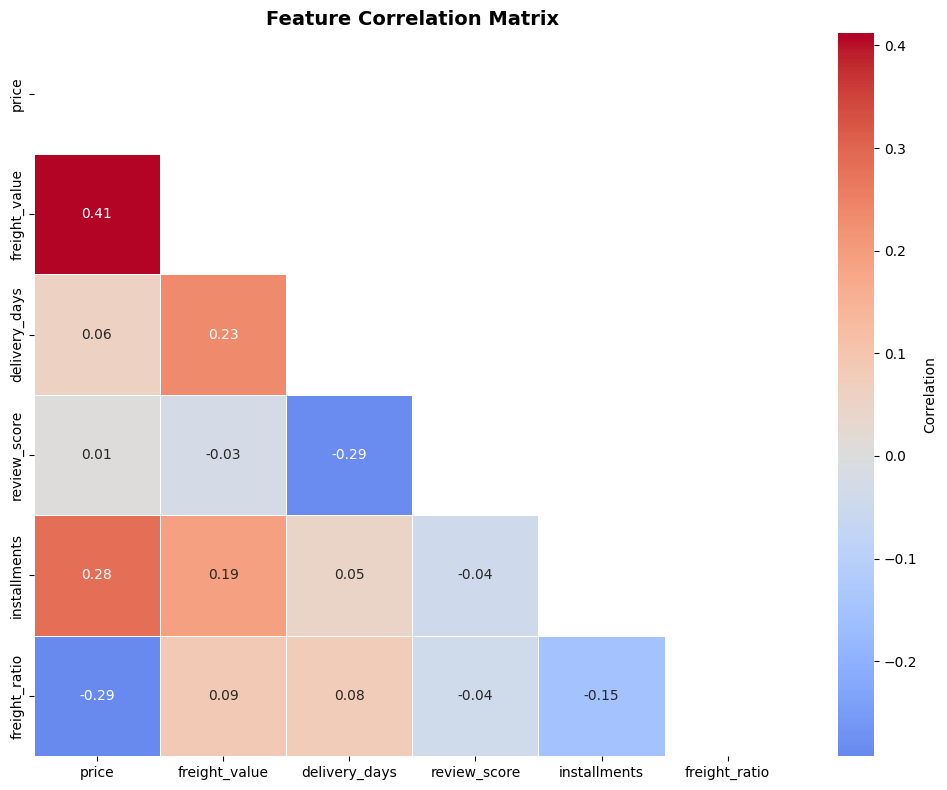


📊 Hypothesis Test: On-Time vs Late Delivery → Review Score
  On-Time Avg Score:  4.211
  Late Avg Score:     2.639
  T-Statistic:        104.5840
  P-Value:            0.000000
  Result: ✅ Significant difference
✅ Statistical analysis complete


In [9]:
# ============================================
# 9. CORRELATION & HYPOTHESIS TESTING
# ============================================

print("📐 Running Statistical Analysis...")

# Correlation matrix
numeric_cols = [
    'price', 'freight_value', 'delivery_days',
    'review_score', 'installments', 'freight_ratio'
]
corr_matrix = master[numeric_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation'}
)
plt.title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(
    os.path.join(data_path, 'correlation_matrix.png'),
    dpi=150, bbox_inches='tight'
)
plt.show()

# Hypothesis Test: On-time vs Late delivery — review score difference
on_time_scores  = master[master['on_time']==True]['review_score'].dropna()
late_scores     = master[master['on_time']==False]['review_score'].dropna()

t_stat, p_value = stats.ttest_ind(on_time_scores, late_scores)

print(f"\n📊 Hypothesis Test: On-Time vs Late Delivery → Review Score")
print(f"  On-Time Avg Score:  {on_time_scores.mean():.3f}")
print(f"  Late Avg Score:     {late_scores.mean():.3f}")
print(f"  T-Statistic:        {t_stat:.4f}")
print(f"  P-Value:            {p_value:.6f}")
print(f"  Result: {'✅ Significant difference' if p_value < 0.05 else '❌ No significant difference'}")

print("✅ Statistical analysis complete")

In [10]:
# ============================================
# 10. SELLER PERFORMANCE ANALYSIS
# ============================================

print("🏪 Running Seller Performance Analysis...")

seller_perf = (
    master.groupby('seller_id')
    .agg(
        total_revenue   = ('item_revenue', 'sum'),
        total_orders    = ('order_id', 'nunique'),
        avg_price       = ('price', 'mean'),
        avg_review      = ('review_score', 'mean'),
        on_time_rate    = ('on_time', 'mean'),
        avg_delivery    = ('delivery_days', 'mean'),
        categories      = ('category_en', 'nunique')
    )
    .round(2)
    .reset_index()
)

# Seller tier
seller_perf['seller_tier'] = pd.qcut(
    seller_perf['total_revenue'],
    q=4,
    labels=['Bronze','Silver','Gold','Platinum']
)

print("\nSeller Tier Summary:")
print(
    seller_perf.groupby('seller_tier')
    .agg(
        sellers       = ('seller_id', 'count'),
        avg_revenue   = ('total_revenue', 'mean'),
        avg_review    = ('avg_review', 'mean'),
        avg_on_time   = ('on_time_rate', 'mean')
    ).round(2)
)

seller_perf.to_csv(
    os.path.join(data_path, 'seller_performance.csv'),
    index=False
)
print("✅ Seller analysis complete")

🏪 Running Seller Performance Analysis...

Seller Tier Summary:
             sellers  avg_revenue  avg_review  avg_on_time
seller_tier                                               
Bronze           741       138.54        4.19         0.92
Silver           741       596.19        4.23         0.93
Gold             740      2113.77        4.17         0.93
Platinum         741     17801.47        4.11         0.93
✅ Seller analysis complete


In [11]:
# ============================================
# 11. AUTOMATED SUMMARY REPORT
# ============================================

print("\n" + "="*60)
print(" FINAL PROJECT SUMMARY REPORT")
print("="*60)

summary = {
    "Dataset":              "Olist Brazilian E-Commerce",
    "Total Records":        f"{len(master):,}",
    "Date Range":           f"{master['order_purchase_timestamp'].min().date()} to {master['order_purchase_timestamp'].max().date()}",
    "Total Revenue":        f"${master['item_revenue'].sum():,.2f}",
    "Total Orders":         f"{master['order_id'].nunique():,}",
    "Total Customers":      f"{master['customer_id'].nunique():,}",
    "Total Sellers":        f"{master['seller_id'].nunique():,}",
    "Top Category":         master.groupby('category_en')['item_revenue'].sum().idxmax(),
    "Avg Delivery Days":    f"{master['delivery_days'].mean():.1f}",
    "On-Time Rate":         f"{master['on_time'].mean()*100:.1f}%",
    "Avg Review Score":     f"{master['review_score'].mean():.2f}/5.0",
    "Champion Customers":   f"{(rfm['segment']=='Champions').sum():,}",
    "At Risk Customers":    f"{(rfm['segment']=='At Risk').sum():,}"
}

for key, val in summary.items():
    print(f"  {key:<25} {val}")

print("\n📁 Files Generated:")
outputs = [
    'master_analytics.csv',
    'rfm_segments.csv',
    'seller_performance.csv',
    'executive_dashboard.png',
    'rfm_analysis.png',
    'cohort_retention.png',
    'outlier_analysis.png',
    'correlation_matrix.png'
]
for f in outputs:
    print(f"  ✅ {f}")

print("\n🎉 Analysis Complete!")


 FINAL PROJECT SUMMARY REPORT
  Dataset                   Olist Brazilian E-Commerce
  Total Records             109,845
  Date Range                2016-10-03 to 2018-08-29
  Total Revenue             $15,299,513.59
  Total Orders              95,577
  Total Customers           95,577
  Total Sellers             2,963
  Top Category              health_beauty
  Avg Delivery Days         11.6
  On-Time Rate              92.9%
  Avg Review Score          4.10/5.0
  Champion Customers        15,201
  At Risk Customers         22,931

📁 Files Generated:
  ✅ master_analytics.csv
  ✅ rfm_segments.csv
  ✅ seller_performance.csv
  ✅ executive_dashboard.png
  ✅ rfm_analysis.png
  ✅ cohort_retention.png
  ✅ outlier_analysis.png
  ✅ correlation_matrix.png

🎉 Analysis Complete!
